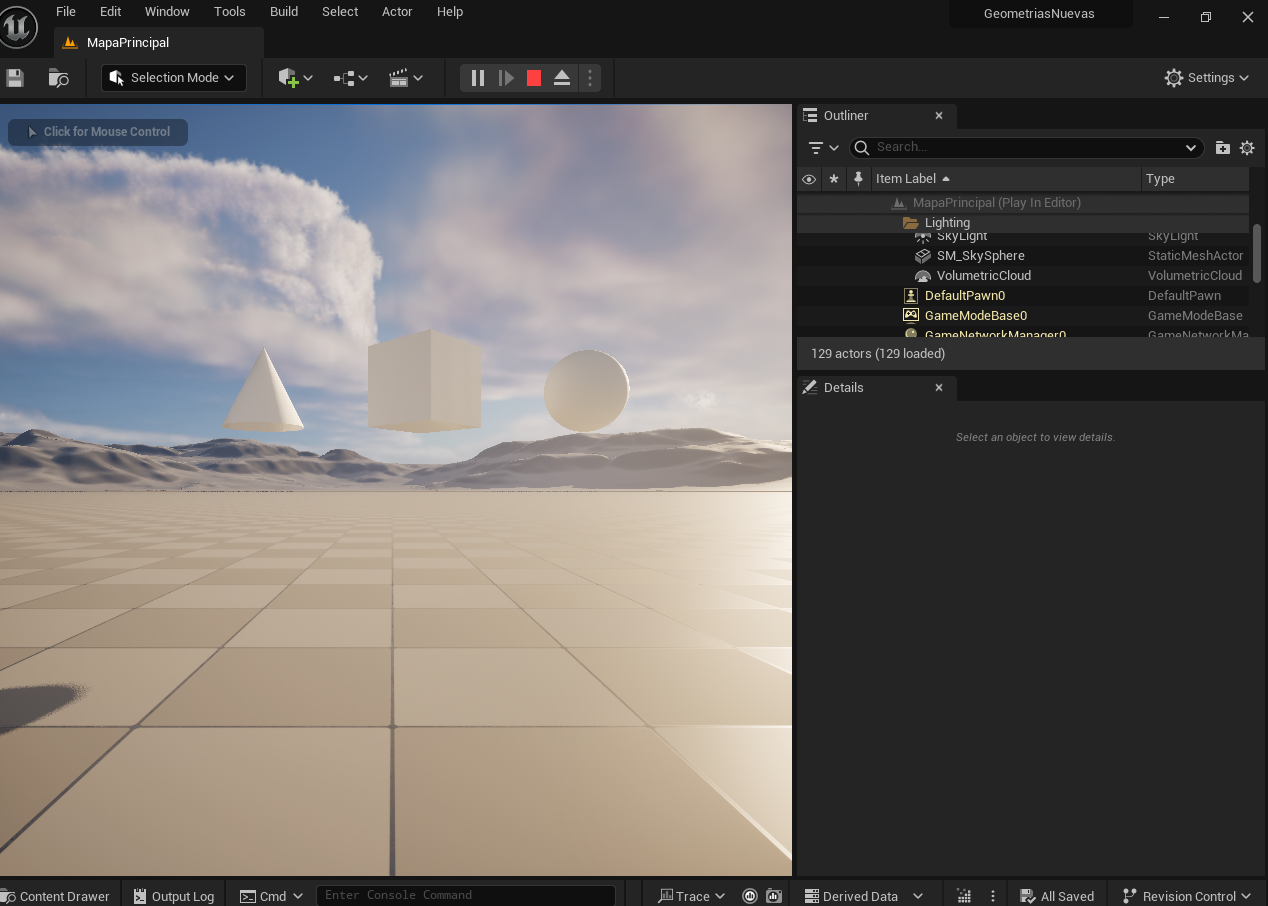


# Notas de Clase: Gestión de Meshes y Materiales en C++

### 1. El Static Mesh (La Forma)
* **Concepto:** Es el modelo 3D (geometría) que define la forma del objeto en el mundo.
* **Carga en C++:** Se utiliza la macro `ConstructorHelpers::FObjectFinder<UStaticMesh>` dentro del constructor.
* **Ruta de Windows:** Las mallas básicas del motor se encuentran físicamente en `C:\Program Files\Epic Games\UE_5.x\Engine\Content\BasicShapes`.
* **Regla de Oro:** En el código, la ruta siempre debe terminar con el nombre del objeto después de un punto (ej: `.Cube`), para que el motor localice el asset dentro del paquete `.uasset`.

### 2. El Material (El Aspecto / Textura)
* **Concepto:** Es el "traje" que viste al Mesh. Define el color, brillo y textura.
* **Carga en C++:** Se usa `ConstructorHelpers::FObjectFinder<UMaterial>`. 
* **Aplicación:** Se asigna mediante la función `SetMaterial(índice, objeto)`. El índice suele ser `0` para objetos simples.
* **Diferencia:** Si no se asigna un material por código, Unreal pone el "WorldGridMaterial" (el de cuadros grises). Al asignar `BasicShapeMaterial`, logramos el acabado blanco limpio.

---

# Código Completo del Proyecto: GeometriasNuevas

## Archivo: MiGeometria.h
```cpp
#pragma once

#include "CoreMinimal.h"
#include "GameFramework/Actor.h"
#include "Components/StaticMeshComponent.h"
#include "Materials/Material.h"
#include "MiGeometria.generated.h"

UCLASS()
class GEOMETRIASNUEVAS_API AMiGeometria : public AActor
{
	GENERATED_BODY()
	
public:	
	AMiGeometria();

protected:
	virtual void BeginPlay() override;

public:	
	virtual void Tick(float DeltaTime) override;

	// Componentes para las figuras declarados para el Editor
	UPROPERTY(VisibleAnywhere, BlueprintReadOnly, Category = "Figuras")
	UStaticMeshComponent* CuboMesh;

	UPROPERTY(VisibleAnywhere, BlueprintReadOnly, Category = "Figuras")
	UStaticMeshComponent* EsferaMesh;

	UPROPERTY(VisibleAnywhere, BlueprintReadOnly, Category = "Figuras")
	UStaticMeshComponent* ConoMesh;
};
```

## Archivo: MiGeometria.cpp
```cpp
#include "Public/MiGeometria.h" // Ajustado para estructura Public/Private
#include "UObject/ConstructorHelpers.h"

AMiGeometria::AMiGeometria()
{
	PrimaryActorTick.bCanEverTick = true;

	// 1. Crear el componente Raíz (Transformación global)
	RootComponent = CreateDefaultSubobject<USceneComponent>(TEXT("Root"));

	// --- CARGA DE ASSETS (Mallas y Materiales) ---
	
	// Buscamos el material blanco limpio en las carpetas del motor
	static ConstructorHelpers::FObjectFinder<UMaterial> MaterialBlanco(TEXT("/Engine/BasicShapes/BasicShapeMaterial.BasicShapeMaterial"));

	// 2. CONFIGURAR EL CUBO
	CuboMesh = CreateDefaultSubobject<UStaticMeshComponent>(TEXT("Cubo"));
	CuboMesh->SetupAttachment(RootComponent);
	static ConstructorHelpers::FObjectFinder<UStaticMesh> MeshCubo(TEXT("/Engine/BasicShapes/Cube.Cube"));
	if (MeshCubo.Succeeded()) CuboMesh->SetStaticMesh(MeshCubo.Object);
	if (MaterialBlanco.Succeeded()) CuboMesh->SetMaterial(0, MaterialBlanco.Object);

	// 3. CONFIGURAR LA ESFERA
	EsferaMesh = CreateDefaultSubobject<UStaticMeshComponent>(TEXT("Esfera"));
	EsferaMesh->SetupAttachment(RootComponent);
	EsferaMesh->SetRelativeLocation(FVector(200.0f, 0.0f, 0.0f)); // Desplazamiento lateral
	static ConstructorHelpers::FObjectFinder<UStaticMesh> MeshEsfera(TEXT("/Engine/BasicShapes/Sphere.Sphere"));
	if (MeshEsfera.Succeeded()) EsferaMesh->SetStaticMesh(MeshEsfera.Object);
	if (MaterialBlanco.Succeeded()) EsferaMesh->SetMaterial(0, MaterialBlanco.Object);

	// 4. CONFIGURAR EL CONO
	ConoMesh = CreateDefaultSubobject<UStaticMeshComponent>(TEXT("Cono"));
	ConoMesh->SetupAttachment(RootComponent);
	ConoMesh->SetRelativeLocation(FVector(-200.0f, 0.0f, 0.0f)); // Desplazamiento lateral opuesto
	static ConstructorHelpers::FObjectFinder<UStaticMesh> MeshCono(TEXT("/Engine/BasicShapes/Cone.Cone"));
	if (MeshCono.Succeeded()) ConoMesh->SetStaticMesh(MeshCono.Object);
	if (MaterialBlanco.Succeeded()) ConoMesh->SetMaterial(0, MaterialBlanco.Object);
}

void AMiGeometria::BeginPlay()
{
	Super::BeginPlay();
}

void AMiGeometria::Tick(float DeltaTime)
{
	Super::Tick(DeltaTime);

	// MOVIMIENTO DINÁMICO
	
	// El cubo rota constantemente en el eje Z (Yaw)
	FRotator RotacionGiro = FRotator(0.0f, 60.0f * DeltaTime, 0.0f);
	CuboMesh->AddRelativeRotation(RotacionGiro);

	// La esfera flota usando una función Seno para suavidad
	float Tiempo = GetWorld()->GetTimeSeconds();
	float Flotacion = FMath::Sin(Tiempo * 3.0f) * 0.6f;
	EsferaMesh->AddRelativeLocation(FVector(0.0f, 0.0f, Flotacion));
}
```

¡Excelente trabajo hoy! Ya tienes las bases de cómo conectar el código con los archivos físicos de Windows. ¿Listo para que en la próxima sesión hagamos que el **Cubo cambie de color** al tocarlo?
